In [2]:
import os
import shutil
from tqdm import tqdm

# Output merged dataset folder
output_base = "/kaggle/working/merged_betel_dataset"

classes = ["Healthy", "Leaf_Rot", "Leaf_Spot", "Dried_Leaf"]

# Create folders
for c in classes:
    os.makedirs(os.path.join(output_base, c), exist_ok=True)

# Dataset 1 paths
dataset1 = {
    "Healthy": "/kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Healthy_Leaf",
    "Leaf_Rot": "/kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Leaf_Rot",
    "Leaf_Spot": "/kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Leaf_Spot"
}

# Dataset 2 paths with mapping
dataset2 = {
    "Leaf_Rot": "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Bacterial Leaf Disease",
    "Dried_Leaf": "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Dried Leaf",
    "Leaf_Spot": "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Fungal Brown Spot Disease",
    "Healthy": "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf"
}

def copy_images(source, target):
    for file in tqdm(os.listdir(source)):
        src = os.path.join(source, file)
        dst = os.path.join(output_base, target, file)
        if os.path.isfile(src):
            shutil.copy(src, dst)

# Copy dataset1
for label, path in dataset1.items():
    copy_images(path, label)

# Copy dataset2
for label, path in dataset2.items():
    copy_images(path, label)

print("Dataset merged successfully!")

100%|██████████| 1/1 [00:00<00:00, 12409.18it/s]

Dataset merged successfully!


In [3]:
import shutil

shutil.make_archive(
    '/kaggle/working/merged_betel_dataset',
    'zip',
    '/kaggle/working/merged_betel_dataset'
)

print("Zip file created!")

Zip file created!


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

In [5]:
dataset_path = "/kaggle/working/merged_betel_dataset"

In [6]:
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

class_counts

{'Leaf_Rot': 269, 'Dried_Leaf': 0, 'Leaf_Spot': 688, 'Healthy': 1080}

In [7]:
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image_Count"])
df

,Class,Image_Count
0,Leaf_Rot,269
1,Dried_Leaf,0
2,Leaf_Spot,688
3,Healthy,1080


In [8]:
total_images = df["Image_Count"].sum()
num_classes = len(df)

print("Total Images:", total_images)
print("Number of Classes:", num_classes)

Total Images: 2037
Number of Classes: 4


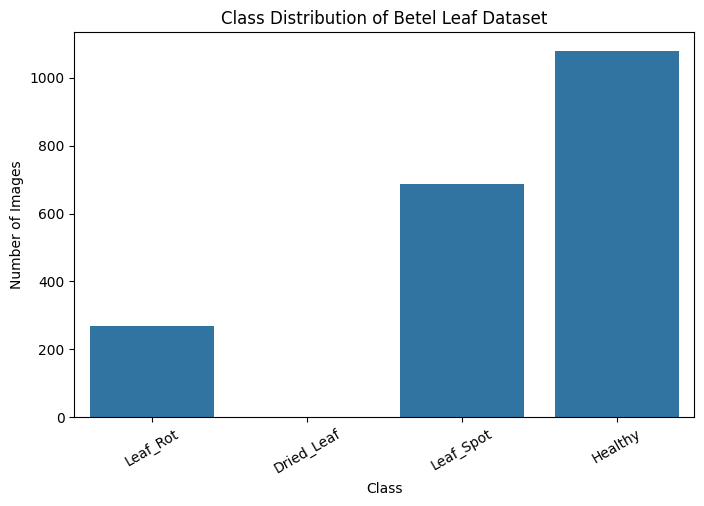

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Class",
    y="Image_Count",
    data=df
)

plt.title("Class Distribution of Betel Leaf Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.show()

In [10]:
widths = []
heights = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)
        
        try:
            image = Image.open(img_path)
            w, h = image.size
            
            widths.append(w)
            heights.append(h)
        except:
            pass

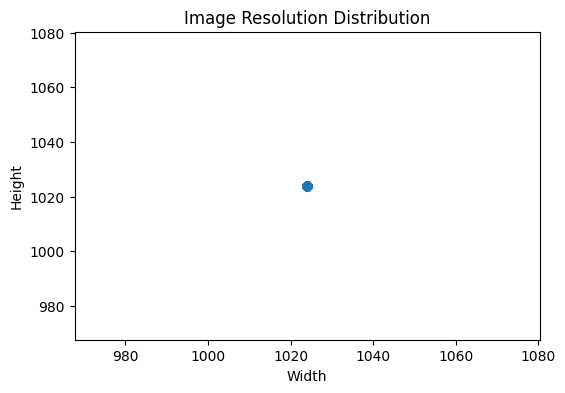

In [11]:
plt.figure(figsize=(6,4))

plt.scatter(widths, heights, alpha=0.5)

plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

Skipping empty folder: Dried_Leaf


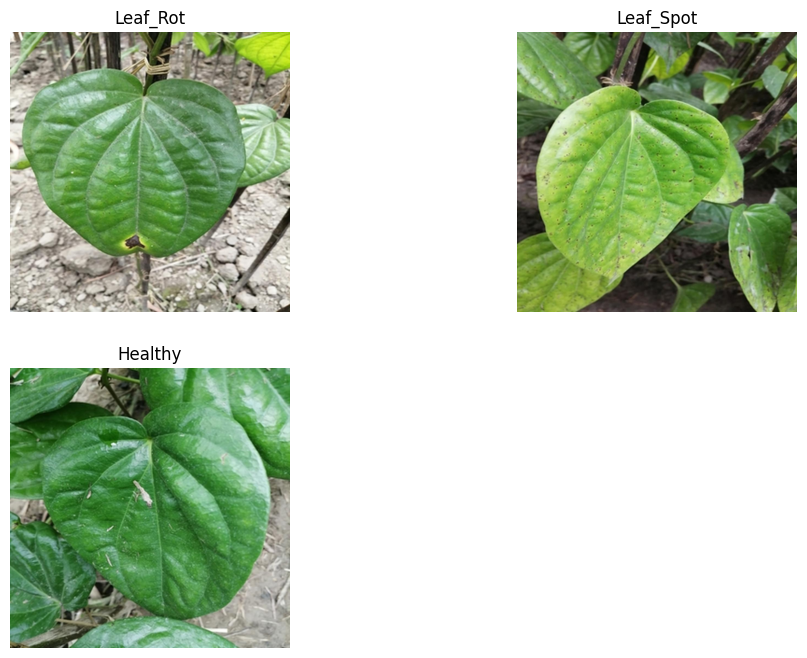

In [12]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/kaggle/working/merged_betel_dataset"

plt.figure(figsize=(12,8))
i = 1

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    # Skip empty folders
    if len(images) == 0:
        print(f"Skipping empty folder: {class_name}")
        continue

    img = random.choice(images)
    img_path = os.path.join(class_path, img)

    image = Image.open(img_path)

    plt.subplot(2,2,i)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

    i += 1

plt.show()

In [13]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        print(class_name, len(os.listdir(class_path)))

Leaf_Rot 269
Dried_Leaf 0
Leaf_Spot 688
Healthy 1080


In [14]:
import os
import shutil
from pathlib import Path

output_base = "/kaggle/working/merged_betel_dataset_final"
classes = ["Healthy", "Leaf_Rot", "Leaf_Spot", "Dried_Leaf"]
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif"}

for c in classes:
    os.makedirs(os.path.join(output_base, c), exist_ok=True)

dataset_map = {
    "Healthy": [
        "/kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Healthy_Leaf",
        "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy Leaf/Healthy Leaf",
    ],
    "Leaf_Rot": [
        "/kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Leaf_Rot",
        "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Bacterial Leaf Disease/Bacterial Leaf Disease/Bacterial Leaf Disease",
    ],
    "Leaf_Spot": [
        "/kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Leaf_Spot",
        "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Fungal Brown Spot Disease/Fungal Brown Spot Disease/Fungal Brown Spot Disease",
    ],
    "Dried_Leaf": [
        "/kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Dried Leaf/Dried Leaf/Dried Leaf",
    ],
}

def copy_images(src_dir, dst_dir, prefix):
    copied = 0

    if not os.path.exists(src_dir):
        print(f"[NOT FOUND] {src_dir}")
        return copied

    for i, fname in enumerate(os.listdir(src_dir)):
        src_path = os.path.join(src_dir, fname)

        if not os.path.isfile(src_path):
            continue

        ext = Path(fname).suffix.lower()
        if ext not in valid_ext:
            continue

        new_name = f"{prefix}_{i}{ext}"
        dst_path = os.path.join(dst_dir, new_name)
        shutil.copy2(src_path, dst_path)
        copied += 1

    print(f"[COPIED] {copied} files from {src_dir}")
    return copied

for cls, src_list in dataset_map.items():
    total = 0
    dst_dir = os.path.join(output_base, cls)

    for j, src in enumerate(src_list):
        total += copy_images(src, dst_dir, f"{cls}_{j}")

    print(f"==> {cls}: total copied = {total}\n")

print("Final merged dataset counts:")
for cls in classes:
    cls_path = os.path.join(output_base, cls)
    count = len([f for f in os.listdir(cls_path) if Path(f).suffix.lower() in valid_ext])
    print(f"{cls}: {count}")

[COPIED] 1080 files from /kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Healthy_Leaf
[COPIED] 250 files from /kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy Leaf/Healthy Leaf
==> Healthy: total copied = 1330

[COPIED] 269 files from /kaggle/input/datasets/mikeafridi/betel-leaf-disease-diagnosis-dataset/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset/Leaf_Rot
[COPIED] 250 files from /kaggle/input/datasets/saadmarjuk/betel-leaf-image-dataset-from-bangladesh/Betel Leaf Image Dataset from Bangladesh/Original Images/Bacterial Leaf Disease/Bacterial Leaf Disease/Bacterial Leaf Disease
==> Leaf_Rot: total copied = 519

[COPI

In [15]:
import os
from pathlib import Path
import pandas as pd

dataset_path = "/kaggle/working/merged_betel_dataset_final"
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif"}

rows = []
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if Path(f).suffix.lower() in valid_ext])
        rows.append([cls, count])

df = pd.DataFrame(rows, columns=["Class", "Image_Count"])
df.loc[len(df)] = ["Total", df["Image_Count"].sum()]
print(df)

        Class  Image_Count
0    Leaf_Rot          519
1  Dried_Leaf          250
2   Leaf_Spot          938
3     Healthy         1330
4       Total         3037


In [16]:
import shutil
shutil.make_archive('/kaggle/working/merged_betel_dataset_final', 'zip', '/kaggle/working/merged_betel_dataset_final')
print("ZIP created successfully.")

ZIP created successfully.


In [17]:
import os
from pathlib import Path
import pandas as pd

dataset_path = "/kaggle/working/merged_betel_dataset_final"
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif"}

rows = []

for cls in sorted(os.listdir(dataset_path)):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if Path(f).suffix.lower() in valid_ext
        ])
        rows.append([cls, count])

df_counts = pd.DataFrame(rows, columns=["Class", "Image_Count"])
df_counts.loc[len(df_counts)] = ["Total", df_counts["Image_Count"].sum()]

print(df_counts)

        Class  Image_Count
0  Dried_Leaf          250
1     Healthy         1330
2    Leaf_Rot          519
3   Leaf_Spot          938
4       Total         3037


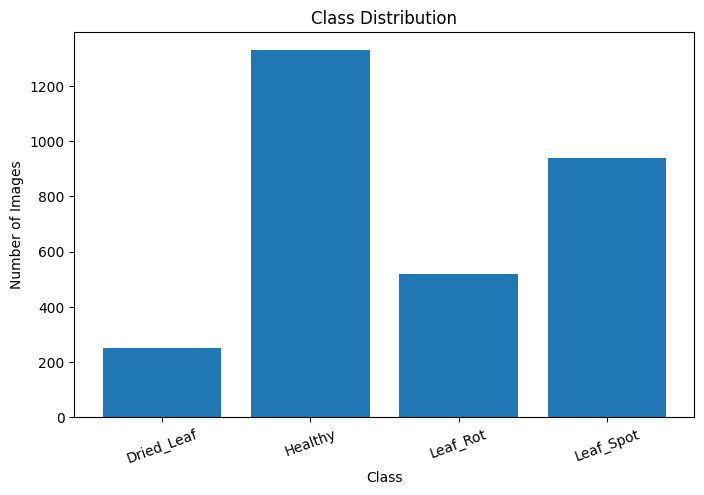

In [18]:
import matplotlib.pyplot as plt

plot_df = df_counts[df_counts["Class"] != "Total"]

plt.figure(figsize=(8,5))
plt.bar(plot_df["Class"], plot_df["Image_Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

In [19]:
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif"))
        ]
        class_counts[class_name] = len(image_files)

df_counts = pd.DataFrame(class_counts.items(), columns=["Class", "Image_Count"])
df_counts = df_counts.sort_values("Class").reset_index(drop=True)

total_images = df_counts["Image_Count"].sum()

print(df_counts)
print("\nTotal Images:", total_images)
print("Number of Classes:", len(df_counts))

        Class  Image_Count
0  Dried_Leaf          250
1     Healthy         1330
2    Leaf_Rot          519
3   Leaf_Spot          938

Total Images: 3037
Number of Classes: 4


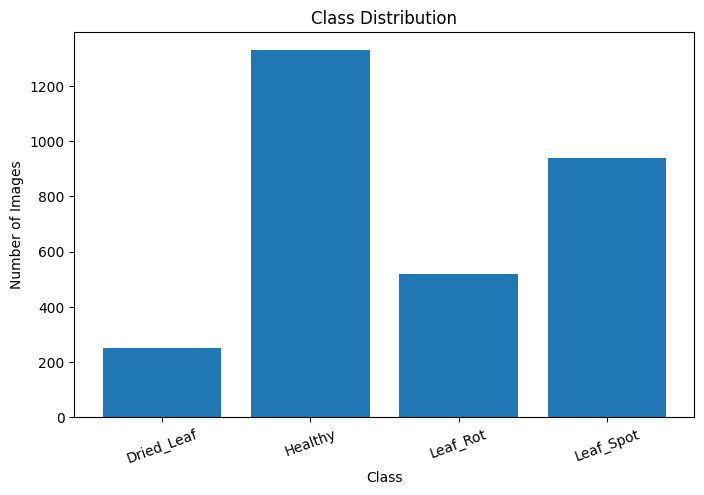

In [20]:
plt.figure(figsize=(8,5))
plt.bar(df_counts["Class"], df_counts["Image_Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

In [21]:
df_summary = df_counts.copy()
df_summary.loc[len(df_summary)] = ["Total", df_summary["Image_Count"].sum()]
df_summary

,Class,Image_Count
0,Dried_Leaf,250
1,Healthy,1330
2,Leaf_Rot,519
3,Leaf_Spot,938
4,Total,3037


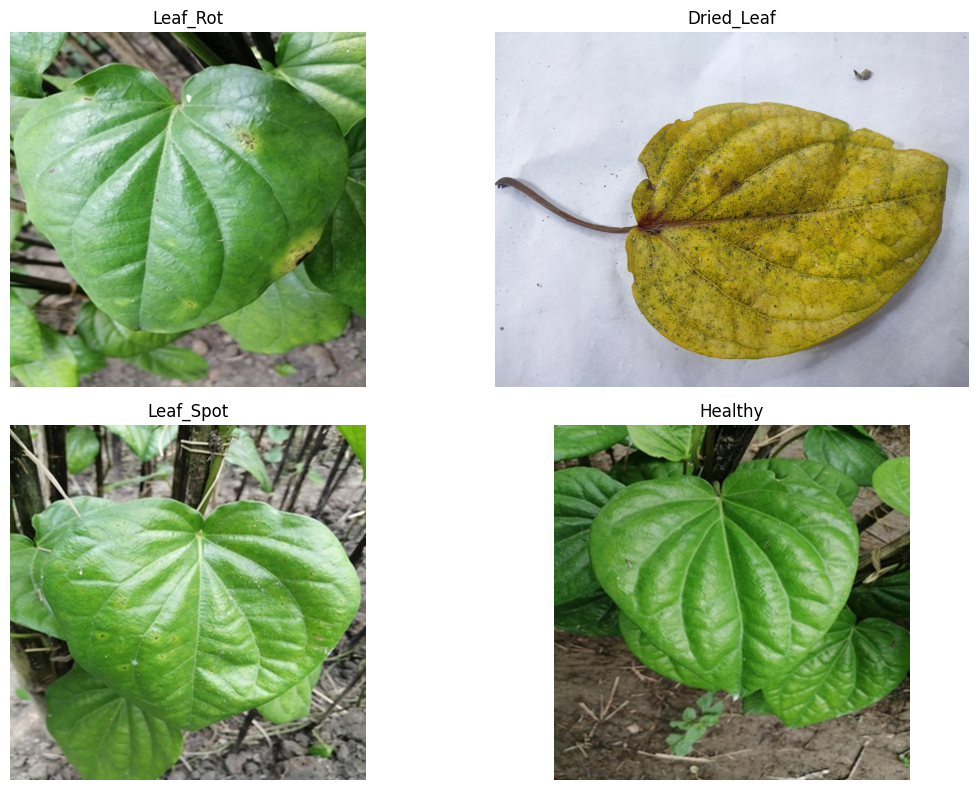

In [22]:
import random
from PIL import Image

classes = [c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))]

plt.figure(figsize=(12,8))
plot_idx = 1

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif"))
    ]
    
    if len(image_files) == 0:
        continue
    
    img_file = random.choice(image_files)
    img_path = os.path.join(class_path, img_file)
    
    img = Image.open(img_path)
    
    plt.subplot(2, 2, plot_idx)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    plot_idx += 1

plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory

2026-03-16 00:08:22.702969: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773619702.872219      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773619702.922346      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773619703.333491      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773619703.333522      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773619703.333525      55 computation_placer.cc:177] computation placer alr

In [24]:
img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 3037 files belonging to 4 classes.
Using 2430 files for training.


I0000 00:00:1773619726.471347      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773619726.477222      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3037 files belonging to 4 classes.
Using 607 files for validation.
Classes: ['Dried_Leaf', 'Healthy', 'Leaf_Rot', 'Leaf_Spot']
Number of classes: 4


In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [26]:
input_layer = layers.Input(shape=(224, 224, 3))

# Branch 1: MobileNetV2
base_model1 = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model1.trainable = False

x1 = base_model1(input_layer, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)

# Branch 2: ResNet50
base_model2 = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model2.trainable = False

x2 = base_model2(input_layer, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)

# Fusion
fusion = layers.Concatenate()([x1, x2])

# Classifier
x = layers.Dense(256, activation="relu")(fusion)
x = layers.Dropout(0.3)(x)
output_layer = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    852,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,698,948 (101.85 MB)

 Trainable params: 853,252 (3.25 MB)

 Non-trainable params: 25,845,696 (98.59 MB)

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


I0000 00:00:1773619742.831203     133 service.cc:152] XLA service 0x77ffc80217f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773619742.831243     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773619742.831249     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773619747.150565     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-16 00:09:15.378172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 00:09:15.515007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773619761.033841     133 device_co

75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6227 - loss: 1.1235

2026-03-16 00:10:07.816596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 00:10:07.953461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.6244 - loss: 1.1177

2026-03-16 00:10:39.673494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 00:10:39.811435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6261 - loss: 1.1121 - val_accuracy: 0.8386 - val_loss: 0.4808
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 48s 623ms/step - accuracy: 0.8756 - loss: 0.3444 - val_accuracy: 0.8451 - val_loss: 0.3770
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 48s 634ms/step - accuracy: 0.9012 - loss: 0.2711 - val_accuracy: 0.8847 - val_loss: 0.3101
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 49s 636ms/step - accuracy: 0.9192 - loss: 0.2350 - val_accuracy: 0.8699 - val_loss: 0.3203
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 49s 644ms/step - accuracy: 0.9286 - loss: 0.2091 - val_accuracy: 0.8913 - val_loss: 0.2636
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 49s 639ms/step - accuracy: 0.9347 - loss: 0.1859 - val_accuracy: 0.8979 - val_loss: 0.2758
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 49s 649ms/step - accuracy: 0.9422 - loss: 0.1638 - val_accuracy: 0.8764 - val_loss: 0.3196
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 49s 639ms/step - accuracy: 0.9345 - loss: 0.1700 - val_accuracy: 0.8863 

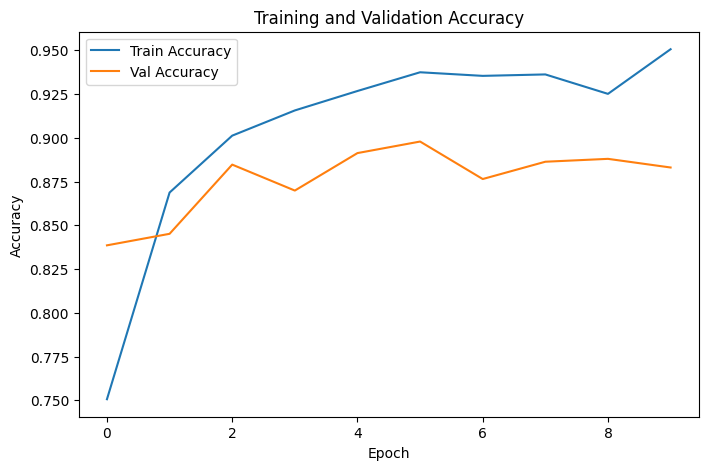

In [29]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

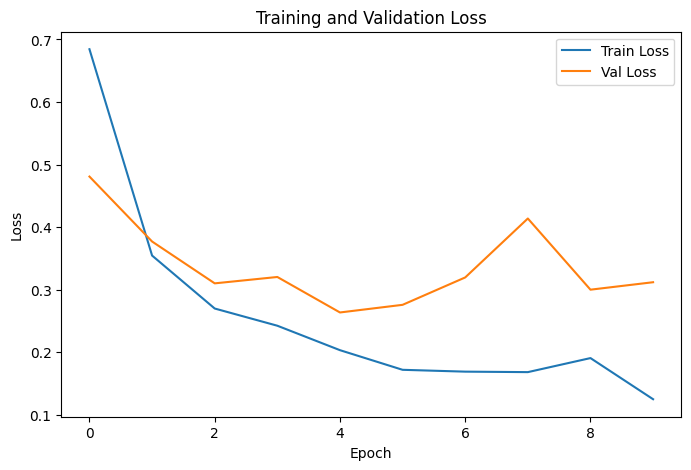

In [30]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [31]:
print("Dataset Summary")
print("----------------")
for _, row in df_counts.iterrows():
    print(f"{row['Class']}: {row['Image_Count']} images")
print(f"Total: {total_images} images")

Dataset Summary
----------------
Dried_Leaf: 250 images
Healthy: 1330 images
Leaf_Rot: 519 images
Leaf_Spot: 938 images
Total: 3037 images
